In [1]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study3.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
outputdirCleaned = os.path.join(topdir, f'data/{study}/Cleaned')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.respon

In [2]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [3]:
import pandas as pd
from scipy.stats import chi2_contingency

participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes = 1 if str(row['feet_discrete_slider.response']).strip() == 'Yes' else 0
    color_yes = 1 if str(row['color_discrete_slider.response']).strip() == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],

        'relevant_dim': row['relevant_dim'],
        'irrelevant_dim': row['irrelevant_dim'],

        'feet_high': row['feet_high'],
        'color_high': row['color_high'],
        'feet_low': row['feet_low'],
        'color_low': row['color_low'],

        'feet_discrete_slider.response': row['feet_discrete_slider.response'],
        'color_discrete_slider.response': row['color_discrete_slider.response'],

        'feet_reported_relevant': feet_yes,
        'color_reported_relevant': color_yes,

        # overfit = selected both dimensions
        'overfit': model_param_score == 2
    })

df_params = pd.DataFrame(participant_rows)

contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    122     95
predict        150     67
Chi-square = 7.180
df = 1
p-value = 0.0074


In [ ]:
df_params['intuitive_relevance'] = (
    df_params['irrelevant_dim'] != 'wing'
).astype(int)

df_params['intuitive_direction'] = (
    df_params['wing_high'] == 'T'
).astype(int)
df_params['task'] = df_params['task'].astype('category')
df_params["overfit"] = df_params["overfit"].astype(int)
print(df_params)
df_params.to_csv(os.path.join(outputdirCleaned, 'df_params_study2_for_r.csv'), index=False)

In [7]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

expected_df = pd.DataFrame(
    expected,
    index=contingency_all.index,
    columns=contingency_all.columns
)

# Row and column proportions
n = contingency_all.values.sum()
row_prop = contingency_all.sum(axis=1) / n
col_prop = contingency_all.sum(axis=0) / n

# Adjusted standardized residuals
adj_resid = (
    contingency_all - expected_df
) / np.sqrt(
    expected_df *
    (1 - row_prop.values[:, None]) *
    (1 - col_prop.values[None, :])
)

print("Observed:")
print(contingency_all)

print("\nExpected:")
print(expected_df.round(2))

print("\nAdjusted standardized residuals:")
print(adj_resid.round(2))
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# p values
pvals = 2 * norm.sf(np.abs(adj_resid.values))

# Holm correction 
_, pvals_holm, _, _ = multipletests(
    pvals.flatten(),
    method="holm"
)

pvals_holm = pd.DataFrame(
    pvals_holm.reshape(adj_resid.shape),
    index=adj_resid.index,
    columns=adj_resid.columns
)

print("\nHolm-adjusted p-values:")
print(pvals_holm.round(4))

model_param_score   0    1   2
task                          
accommodate        23   99  95
predict            41  109  67
Chi-square = 10.383
df = 2
p-value = 0.0056
Observed:
model_param_score   0    1   2
task                          
accommodate        23   99  95
predict            41  109  67

Expected:
model_param_score     0      1     2
task                                
accommodate        32.0  104.0  81.0
predict            32.0  104.0  81.0

Adjusted standardized residuals:
model_param_score     0     1     2
task                               
accommodate       -2.44 -0.96  2.78
predict            2.44  0.96 -2.78

Holm-adjusted p-values:
model_param_score       0       1       2
task                                     
accommodate        0.0593  0.6732  0.0327
predict            0.0593  0.6732  0.0327


model_param_score   0    1   2
task                          
accommodate        23   99  95
predict            41  109  67
Chi-square = 10.383
df = 2
p-value = 0.0056


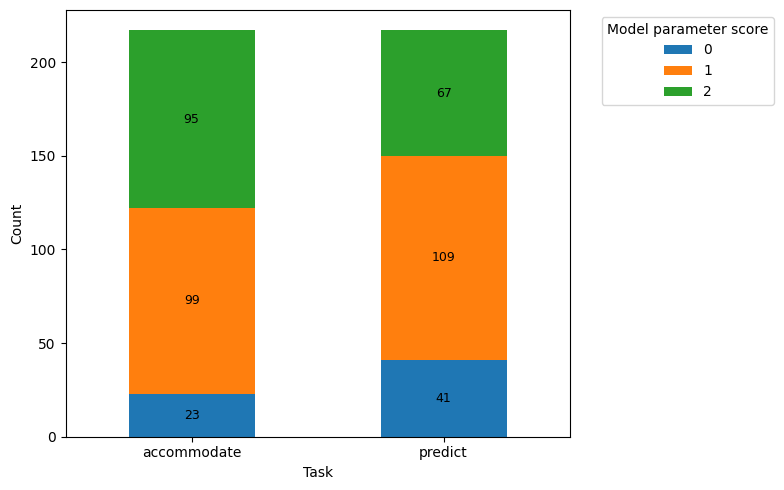

In [ ]:
ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
plt.show()
plt.close()